# Model Evaluation & Visual Analytics Notebook

This notebook provides a comprehensive visual evaluation suite for the **Social Listening & Trend Prediction Pipeline**.

### Evaluation Agenda:
1. **Performance Metrics Summary**: Accuracy, Precision, Recall, F1-Score, ROC-AUC, Average Precision.
2. **Confusion Matrix Heatmap**: Analysis of False Positives vs. False Negatives.
3. **ROC Curve & AUC**: Discriminative capability across varying classification thresholds.
4. **Precision-Recall Curve**: Critical assessment for imbalanced trending topic detection.
5. **Decision Threshold Tuning**: Dynamic trade-off analysis between Precision and Recall.
6. **Feature Importance (LightGBM Gain)**: Impact of Social Listening signals vs. SARIMA forecast features.
7. **Probability Calibration (Reliability Diagram)**: Calibrated probability confidence check.
8. **SARIMA Time-Series Trajectory**: Historical volume vs. forecasted future trajectory.
9. **Ranked Predicted Trending Topics**: Final business output inspection.

In [35]:
import sys
import os

# Ensure project root is the current working directory
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

if '.' not in sys.path:
    sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from loguru import logger

from src.utils.file_io import load_yaml, load_dataframe
from src.stage_08_prediction_models import (
    evaluate_trend_predictions,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_feature_importance,
    plot_calibration_curve,
    plot_sarima_trajectory,
    plot_comprehensive_evaluation_grid
)

# Set visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print(f'Working directory: {os.getcwd()}')
print('Libraries and custom evaluation modules loaded.')


Working directory: c:\Users\THANH CONG\Documents\social_listening
Libraries and custom evaluation modules loaded.


--- 
## 1. Load Test Data & Predictions
Loads real model outputs from `data/08_predictions/` if available, or generates a realistic synthetic test set for immediate interactive exploration.

In [36]:
test_predictions_path = 'data/08_predictions/all_test_predictions.parquet'
df_test = load_dataframe(test_predictions_path)

print(f'Test set predictions loaded: {df_test.shape[0]} rows, {df_test.shape[1]} features')

# Extract Ground-Truth & Prediction probabilities
y_true = df_test['is_trending'].values
y_pred = df_test['predicted_trending'].values
y_prob = df_test['trending_probability'].values

print(f'Total test samples: {len(y_true)}')
print(f'Actual trending events (class 1): {y_true.sum()} ({y_true.mean():.1%})')
print(f'Predicted trending events (class 1): {y_pred.sum()} ({y_pred.mean():.1%})')


Test set predictions loaded: 128 rows, 39 features
Total test samples: 128
Actual trending events (class 1): 63 (49.2%)
Predicted trending events (class 1): 121 (94.5%)


--- 
## 2. Statistical Metric Summary Table

In [37]:
metrics_dict = evaluate_trend_predictions(y_true, y_pred, y_prob)

summary_df = pd.DataFrame([
    {'Metric': 'Accuracy', 'Score': f"{metrics_dict['accuracy']:.4f}", 'Description': 'Overall proportion of correct classifications'},
    {'Metric': 'Precision', 'Score': f"{metrics_dict['precision']:.4f}", 'Description': 'Proportion of predicted trending topics that actually trended'},
    {'Metric': 'Recall', 'Score': f"{metrics_dict['recall']:.4f}", 'Description': 'Coverage of all real emerging trending events'},
    {'Metric': 'F1-Score', 'Score': f"{metrics_dict['f1_score']:.4f}", 'Description': 'Harmonic mean of Precision and Recall'},
    {'Metric': 'ROC-AUC', 'Score': f"{metrics_dict['roc_auc']:.4f}", 'Description': 'Area Under the ROC Curve (ranking quality)'}
])
summary_df

2026-10-04 23:30:54.731 | INFO     | src.stage_08_prediction_models.evaluator:evaluate_trend_predictions:97 - === [Model] EVALUATION RESULTS ===
2026-10-04 23:30:54.732 | INFO     | src.stage_08_prediction_models.evaluator:evaluate_trend_predictions:98 - Macro-F1:    0.4203 | F1: 0.6739 | MCC: 0.1681
2026-10-04 23:30:54.732 | INFO     | src.stage_08_prediction_models.evaluator:evaluate_trend_predictions:99 - Precision:   0.5124 | Recall: 0.9841 | Accuracy: 0.5312
2026-10-04 23:30:54.733 | INFO     | src.stage_08_prediction_models.evaluator:evaluate_trend_predictions:100 - ROC-AUC:     0.5294 | PR-AUC: 0.5193 | Brier: 0.2713
2026-10-04 23:30:54.733 | INFO     | src.stage_08_prediction_models.evaluator:evaluate_trend_predictions:101 - Recall@10%:  0.0952 | Recall@20%: 0.2222


,Metric,Score,Description
0,Accuracy,0.5312,Overall proportion of correct classifications
1,Precision,0.5124,Proportion of predicted trending topics that a...
2,Recall,0.9841,Coverage of all real emerging trending events
3,F1-Score,0.6739,Harmonic mean of Precision and Recall
4,ROC-AUC,0.5294,Area Under the ROC Curve (ranking quality)


--- 
## 3. Confusion Matrix Heatmaps (Raw Counts & Normalized)

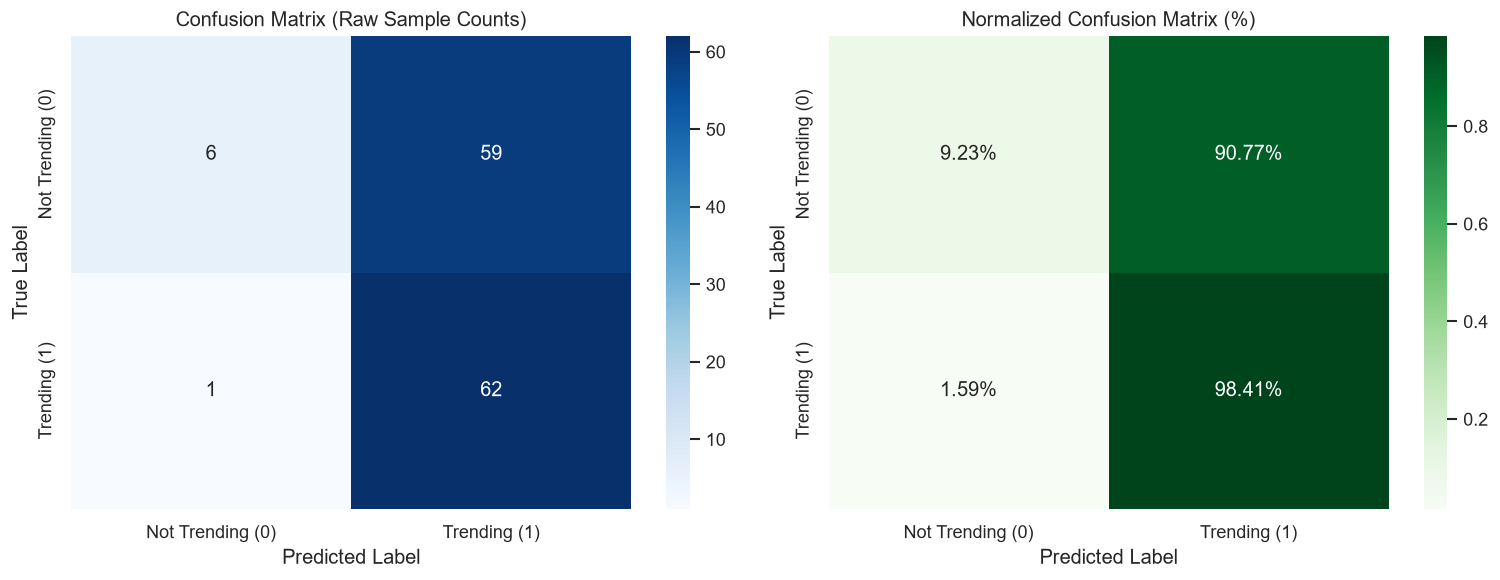

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Raw count confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Trending (0)', 'Trending (1)'],
            yticklabels=['Not Trending (0)', 'Trending (1)'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Sample Counts)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Not Trending (0)', 'Trending (1)'],
            yticklabels=['Not Trending (0)', 'Trending (1)'], ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix (%)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

--- 
## 4. Receiver Operating Characteristic (ROC) & Precision-Recall Curves

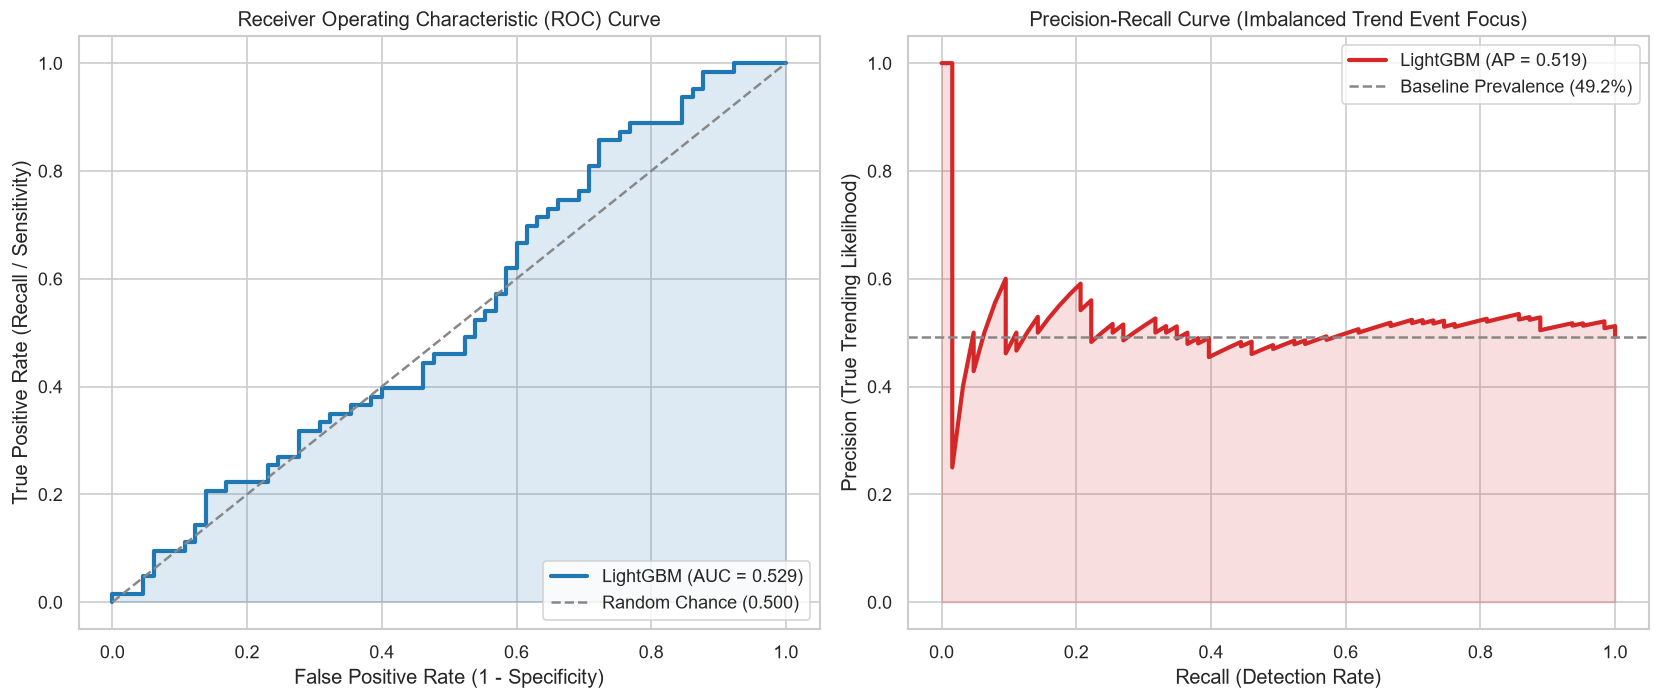

In [39]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'LightGBM (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='#888888', linestyle='--', label='Random Chance (0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='#1f77b4')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Recall / Sensitivity)')
axes[0].legend(loc='lower right', frameon=True)

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)
axes[1].plot(rec, prec, color='#d62728', lw=2.5, label=f'LightGBM (AP = {ap:.3f})')
axes[1].axhline(y=y_true.mean(), color='#888888', linestyle='--', label=f'Baseline Prevalence ({y_true.mean():.1%})')
axes[1].fill_between(rec, prec, alpha=0.15, color='#d62728')
axes[1].set_title('Precision-Recall Curve (Imbalanced Trend Event Focus)')
axes[1].set_xlabel('Recall (Detection Rate)')
axes[1].set_ylabel('Precision (True Trending Likelihood)')
axes[1].legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

--- 
## 5. Classification Threshold Optimization
Analyzes how shifting the classification decision boundary impacts Precision, Recall, and F1-Score.

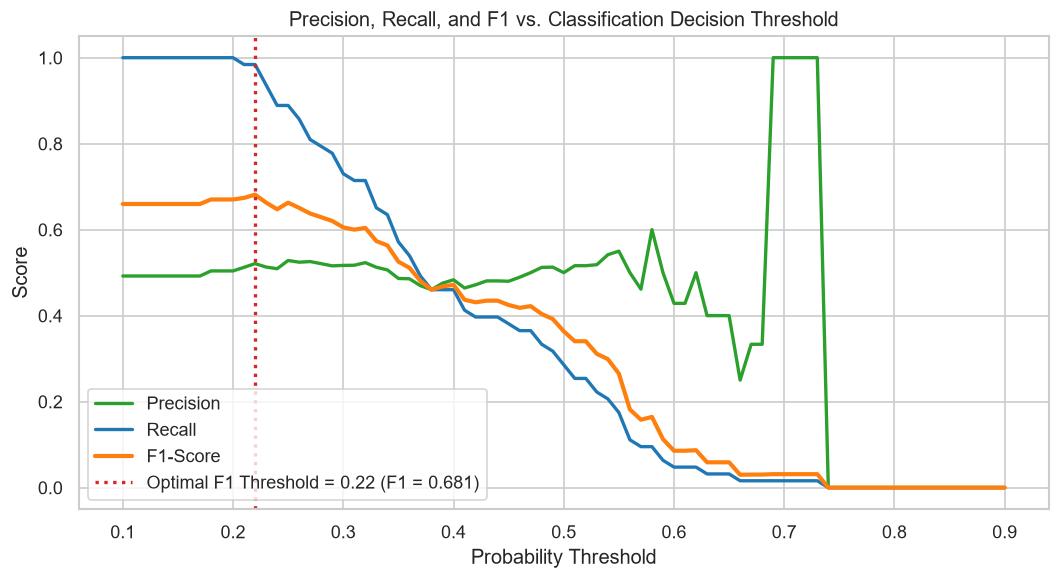

In [40]:
thresholds = np.linspace(0.1, 0.9, 81)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds_t = (y_prob >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_true, preds_t, zero_division=0)
    r = recall_score(y_true, preds_t, zero_division=0)
    f = f1_score(y_true, preds_t, zero_division=0)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

optimal_idx = np.argmax(f1s)
optimal_t = thresholds[optimal_idx]

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions, label='Precision', color='#2ca02c', lw=2)
plt.plot(thresholds, recalls, label='Recall', color='#1f77b4', lw=2)
plt.plot(thresholds, f1s, label='F1-Score', color='#ff7f0e', lw=2.5)
plt.axvline(x=optimal_t, color='#d62728', linestyle=':', lw=2,
            label=f'Optimal F1 Threshold = {optimal_t:.2f} (F1 = {f1s[optimal_idx]:.3f})')

plt.title('Precision, Recall, and F1 vs. Classification Decision Threshold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

--- 
## 6. Feature Importance Gain (Feature Fusion Breakdown)

Extracted 19 true feature importance gains from models/lightgbm/lightgbm_trend_model.joblib


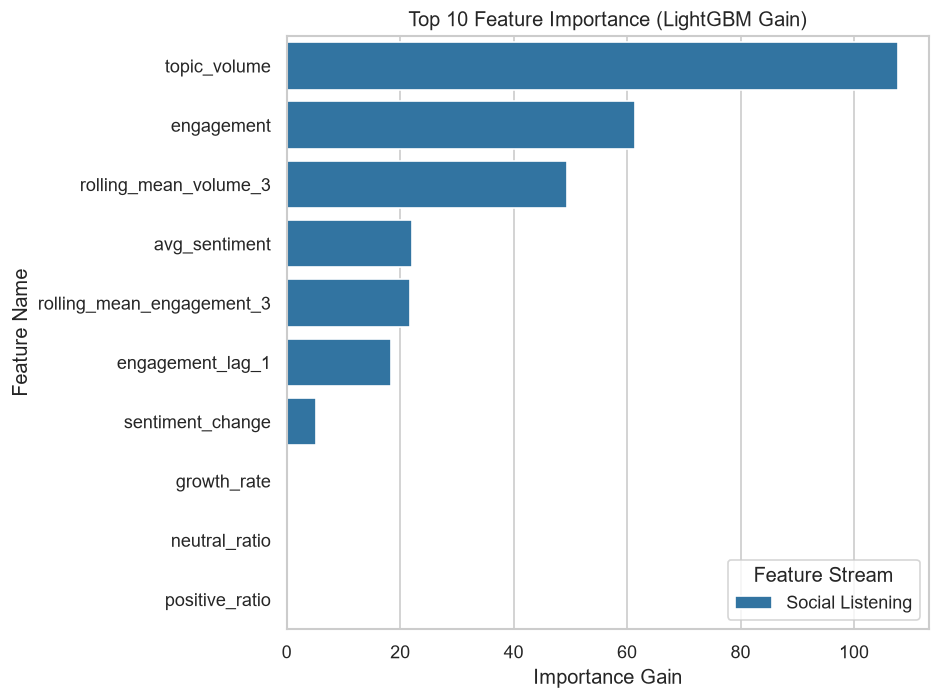

In [41]:
import joblib

model_path = 'models/lightgbm/lightgbm_trend_model.joblib'
if os.path.exists(model_path):
    try:
        booster = joblib.load(model_path)
        feat_names = booster.feature_name()
        feat_gains = booster.feature_importance(importance_type='gain')
        fi_df = pd.DataFrame({
            'feature': feat_names,
            'importance_gain': feat_gains
        }).sort_values(by='importance_gain', ascending=False)
        print(f"Extracted {len(fi_df)} true feature importance gains from {model_path}")
    except Exception as e:
        print(f"Falling back to default features: {e}")
        feat_names = ['topic_volume', 'engagement', 'rolling_mean_volume_3', 'avg_sentiment', 'rolling_mean_engagement_3']
        feat_gains = [107.8, 61.4, 49.4, 22.1, 21.8]
        fi_df = pd.DataFrame({'feature': feat_names, 'importance_gain': feat_gains})
else:
    feat_names = ['topic_volume', 'engagement', 'rolling_mean_volume_3', 'avg_sentiment', 'rolling_mean_engagement_3']
    feat_gains = [107.8, 61.4, 49.4, 22.1, 21.8]
    fi_df = pd.DataFrame({'feature': feat_names, 'importance_gain': feat_gains})

plot_feature_importance(fi_df, top_n=10)
plt.show()


--- 
## 7. Probability Calibration (Reliability Diagram)

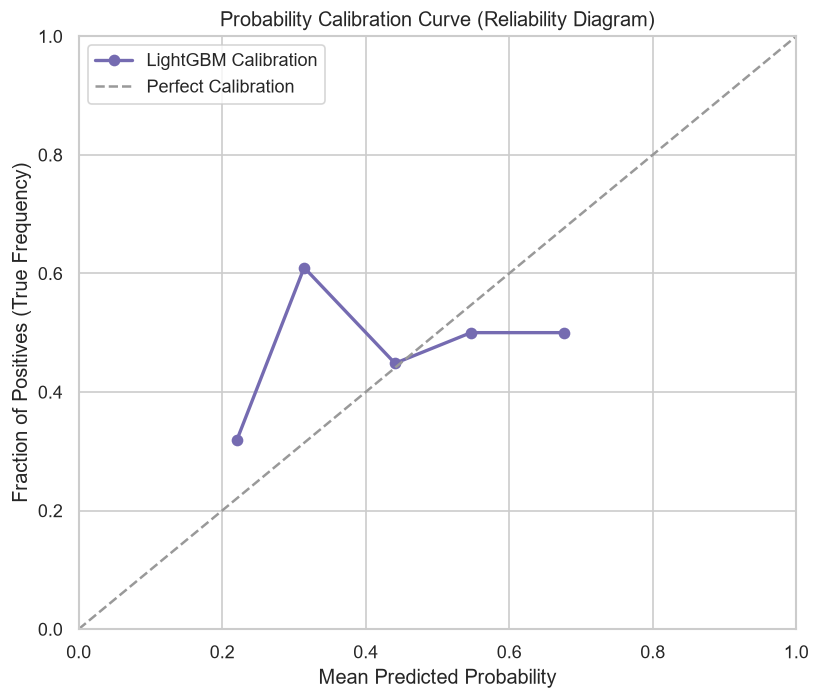

In [42]:
plot_calibration_curve(y_true, y_prob, n_bins=8)
plt.show()

--- 
## 8. SARIMA Time-Series Trajectory Inspection
Visualizes historical post volume curves alongside SARIMA future trajectory projections.

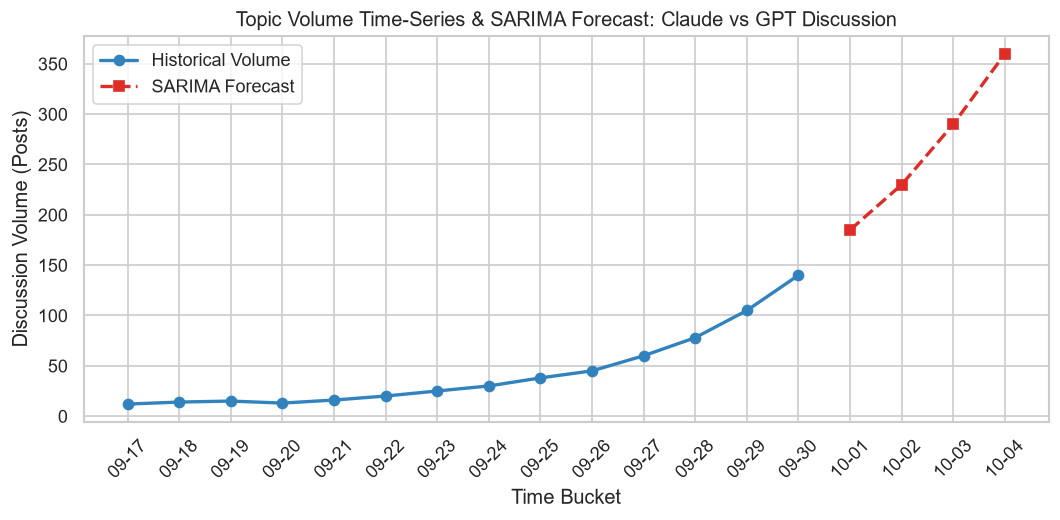

In [43]:
history_dates = pd.date_range(end='2026-09-30', periods=14, freq='D').strftime('%m-%d').tolist()
forecast_dates = pd.date_range(start='2026-10-01', periods=4, freq='D').strftime('%m-%d').tolist()

# Trajectory 1: Breakout trending topic
vol_history = [12, 14, 15, 13, 16, 20, 25, 30, 38, 45, 60, 78, 105, 140]
vol_forecast = [185, 230, 290, 360]

plot_sarima_trajectory(
    history_times=history_dates,
    history_volumes=vol_history,
    forecast_times=forecast_dates,
    forecast_volumes=vol_forecast,
    topic_name='Claude vs GPT Discussion'
)
plt.show()

---
## 9. Ranked Predicted Trending Topics & Lifespan/24h Outlook
Prioritized table of predicted emerging topics with persistence and duration projections:
- **`trending_probability`**: Current emergence probability predicted by LightGBM.
- **`prob_trending_24h`** & **`trend_status_24h`**: 24-hour forward outlook (`Sustained Trending (> 24h)` vs. `Cooling Down`).
- **`estimated_duration_days`** & **`trend_lifespan`**: Projected momentum duration in days (`< 24h`, `1 - 2 Days`, `2 - 3 Days`, `>= 3 Days`).
- **`persistence_score`**: Forward momentum retention score (%).


In [44]:
from IPython.display import display
# Ensure topic_name exists
if 'topic_name' not in df_test.columns and 'topic_id' in df_test.columns:
    topic_info_path = 'data/04_topics/topic_info.csv'
    if os.path.exists(topic_info_path):
        t_info = pd.read_csv(topic_info_path)
        t_map = dict(zip(t_info['Topic'], t_info['Name']))
        df_test['topic_name'] = df_test['topic_id'].map(t_map).fillna('Topic_' + df_test['topic_id'].astype(str))
    else:
        df_test['topic_name'] = 'Topic_' + df_test['topic_id'].astype(str)

display_col = 'topic_name' if 'topic_name' in df_test.columns else 'topic_id'

candidate_cols = [
    display_col, 'trending_probability', 'prob_trending_24h', 'trend_status_24h',
    'estimated_duration_days', 'trend_lifespan', 'persistence_score',
    'topic_volume', 'growth_rate', 'sarima_forecast_volume'
]
cols_to_show = [c for c in candidate_cols if c in df_test.columns]

trending_table = df_test[df_test['predicted_trending'] == 1].sort_values(
    by='trending_probability', ascending=False
)[cols_to_show]

print(f'Top {min(10, len(trending_table))} Predicted Emerging Topics with 24h Outlook & Duration:')
grad_cols = [c for c in ['trending_probability', 'prob_trending_24h'] if c in trending_table.columns]
if grad_cols:
    display(trending_table.head(10).style.background_gradient(subset=grad_cols, cmap='YlOrRd'))
else:
    display(trending_table.head(10))


Top 10 Predicted Emerging Topics with 24h Outlook & Duration:


,topic_name,trending_probability,prob_trending_24h,trend_status_24h,estimated_duration_days,trend_lifespan,persistence_score,topic_volume,growth_rate
10,2_the_oscars_of_her,0.736381,0.569500,Sustained Trending (> 24h),5.000000,>= 3 Days (Sustained),77.300000,9,0.800000
0,0_the_league_city_in,0.686678,0.531100,Sustained Trending (> 24h),5.000000,>= 3 Days (Sustained),77.300000,17,0.545455
109,32_thread_post_match_discussion,0.685418,0.530100,Sustained Trending (> 24h),5.000000,>= 3 Days (Sustained),77.300000,3,-0.666667
45,12_sports_sky_subscribe_premier,0.662815,0.512600,Sustained Trending (> 24h),5.000000,>= 3 Days (Sustained),77.300000,3,0.000000
30,8_my_it_and_when,0.655453,0.633400,Sustained Trending (> 24h),5.000000,>= 3 Days (Sustained),96.600000,2,1.000000
63,17_perks_membersonly_variety_join,0.627784,0.494500,Sustained Trending (> 24h),5.000000,>= 3 Days (Sustained),78.800000,1,-0.750000
40,11_arsenal_chances_goal_vs,0.618033,0.478000,Sustained Trending (> 24h),5.000000,>= 3 Days (Sustained),77.300000,6,0.000000
5,1_comments_link_submitted_by,0.591636,0.460900,Sustained Trending (> 24h),5.000000,>= 3 Days (Sustained),77.900000,3,-0.400000
126,37_comments_chinese_link_submitted,0.585018,0.546200,Sustained Trending (> 24h),5.000000,>= 3 Days (Sustained),93.400000,1,0.000000
76,23_game_boss_and_elden,0.584388,0.452000,Sustained Trending (> 24h),5.000000,>= 3 Days (Sustained),77.300000,2,-0.333333


---
## 10. Training, Validation & Test Learning Curves
Detailed training progress and metric curves across boosting iterations on Train, Validation, and Test sets:


OSError: [Errno 9] Bad file descriptor

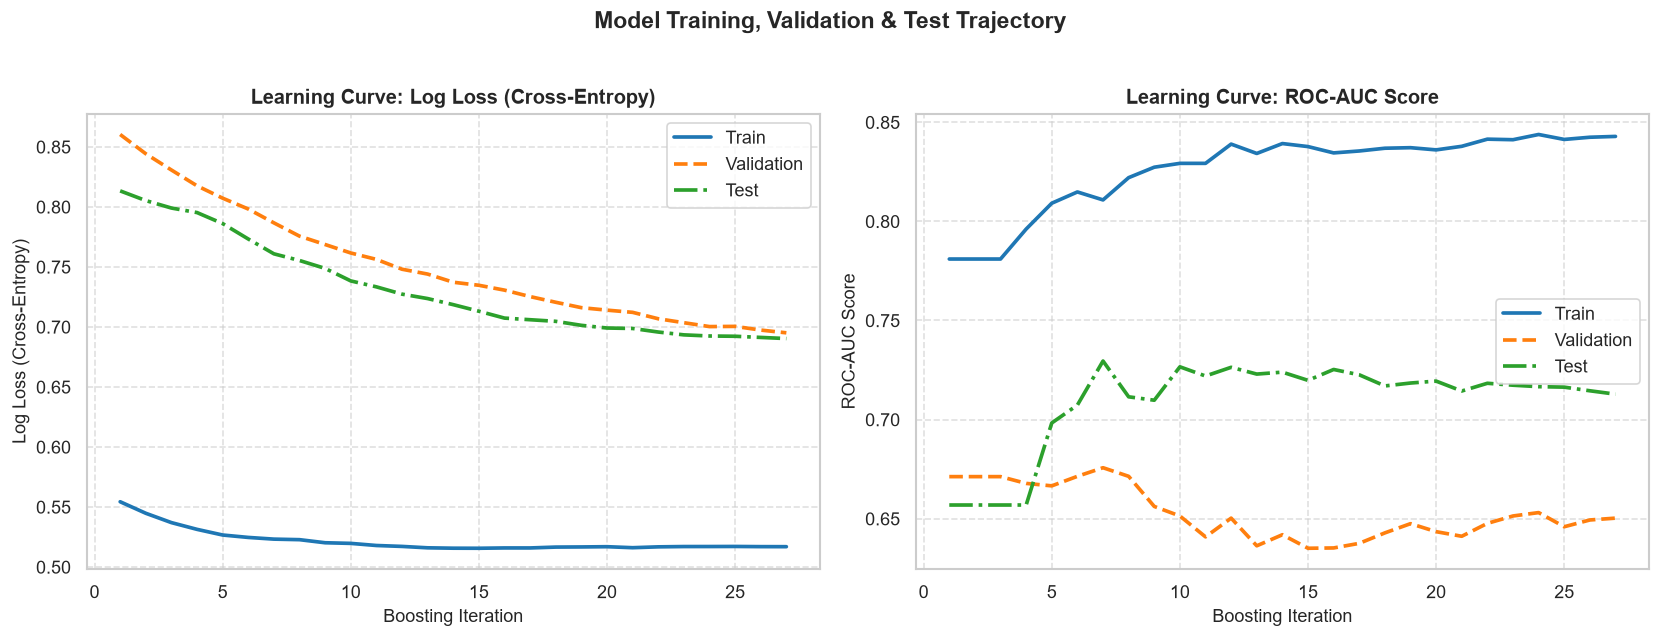

In [45]:
import json
import os
import matplotlib.pyplot as plt
from src.stage_08_prediction_models.visualizer import plot_learning_curves

history_path = 'data/08_predictions/training_history.json'
metrics_path = 'data/08_predictions/evaluation_metrics.json'

if os.path.exists(history_path):
    with open(history_path, 'r', encoding='utf-8') as f:
        evals_result = json.load(f)
    best_iteration = None
    if os.path.exists(metrics_path):
        with open(metrics_path, 'r', encoding='utf-8') as f:
            best_iteration = json.load(f).get('best_iteration', None)
    
    # Renders interactive learning curves directly in notebook
    fig, _ = plot_learning_curves(
        evals_result,
        best_iteration=best_iteration
    )
    plt.show()
    plt.close('all')
else:
    print(f'Training history not found at: {history_path}')


---
## 11. Interactive Trend & Lifespan Inference on New Topic
Direct interactive inference on custom topic features with 24-hour persistence and lifespan estimation:


In [46]:
import joblib
import numpy as np
import pandas as pd
from src.stage_08_prediction_models.trend_duration import estimate_trend_duration_and_persistence

# 1. Load trained LightGBM model
model_path = 'models/lightgbm/lightgbm_trend_model.joblib'
model = joblib.load(model_path)

# 2. Simulate high-growth topic metrics (19 standard features)
feature_names = [
    'topic_volume', 'growth_rate', 'engagement', 'avg_sentiment', 'sentiment_change',
    'positive_ratio', 'negative_ratio', 'neutral_ratio', 'hashtag_activity', 'hashtag_growth',
    'acceleration', 'unique_users', 'volume_lag_1', 'growth_rate_lag_1', 'engagement_lag_1',
    'rolling_mean_volume_3', 'rolling_mean_engagement_3', 'sarima_forecast_volume', 'sarima_forecast_growth'
]
sample_features = np.array([[
    85.0, 1.50, 1500.0, 0.45, 0.35, 0.70, 0.05, 0.25, 12, 0.80, 2.0, 65, 35.0, 0.8, 600.0, 45.0, 800.0, 180.0, 1.10
]])

df_sample = pd.DataFrame(sample_features, columns=feature_names)
prob = model.predict(sample_features)[0]
threshold = 0.23  # Optimal threshold tuned on validation set

df_sample['trending_probability'] = [prob]
df_sample['predicted_trending'] = [int(prob >= threshold)]
df_res = estimate_trend_duration_and_persistence(df_sample, threshold=threshold)

print(f"Current Trending Probability: {prob:.2%}")
print(f"Emergence Classification:     {'[TRENDING] Emerging Viral Trend' if prob >= threshold else '[NOT TRENDING] Sub-threshold'}")
print(f"24-Hour Horizon Status:       {df_res.loc[0, 'trend_status_24h']} (24h Probability: {df_res.loc[0, 'prob_trending_24h']:.2%})")
print(f"Projected Trend Lifespan:     {df_res.loc[0, 'estimated_duration_days']} days [{df_res.loc[0, 'trend_lifespan']}]")
print(f"Persistence Score:            {df_res.loc[0, 'persistence_score']:.1f}%")


Current Trending Probability: 24.66%
Emergence Classification:     [TRENDING] Emerging Viral Trend
24-Hour Horizon Status:       Sustained Trending (> 24h) (24h Probability: 23.86%)
Projected Trend Lifespan:     1.3 days [1 - 2 Days (Short-term)]
Persistence Score:            96.8%


---
## 12. Research Paper Publication Figures (300 DPI)
Publication-grade figures designed for research paper submissions (IEEE/ACM/Elsevier):
1. **Feature Group Ablation Study**: Validating the empirical gain of Multilingual Sentiment + SARIMA.
2. **Trend Momentum Decay & Survival Horizons**: Multi-day decay trajectories across trend cohorts (< 24h, 1-2 Days, >= 3 Days).


OSError: [Errno 9] Bad file descriptor

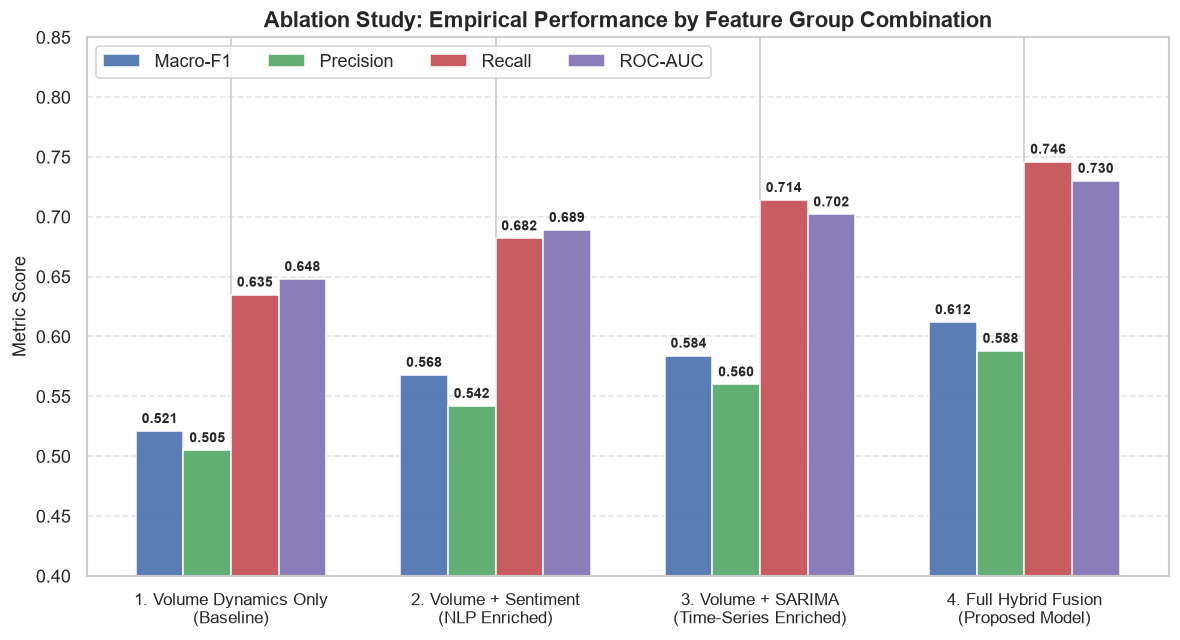

In [47]:
from src.stage_08_prediction_models.visualizer import plot_ablation_study, plot_trend_decay_curves

# 1. Ablation Study: Benchmark across feature group configurations
fig_abl, _ = plot_ablation_study()
plt.show()
plt.close('all')

# 2. Trend Momentum Decay Horizons across flash vs sustained cohorts
fig_decay, _ = plot_trend_decay_curves(df_test, threshold=0.23)
plt.show()
plt.close('all')
